In [10]:
import sys
from pathlib import Path

import matplotlib.pyplot
import matplotlib.ticker
import numpy
import pandas

sys.path.insert(0, "..")
from runner.utils import load_benchmark_metadata

In [5]:
def load_results(folder: str | list[str]):
    """Loads all CSV files in `folder`. Returns the results and variability dataframes."""
    folders = folder if isinstance(folder, list) else [folder]
    csv_files = [p for f in folders for p in Path(f).glob("*.csv")]
    results = pandas.concat([pandas.read_csv(p) for p in csv_files]).reset_index(
        drop=True
    )

    # Remove reference benchmark
    results = results.query('Benchmark != "reference-benchmark"')

    # Print some basic stats
    results["bench-size"] = results["Benchmark"] + "-" + results["Size"]
    results["solver-version"] = results["Solver"] + "-" + results["Solver Version"]
    print(
        f"Found {len(results)} records, {len(results['bench-size'].unique())} benchmark instances"
    )
    return results

## Load the results and metadata, and prepare the data for plotting.

In [6]:
# Load the CSV files containing the reults of the PyPSA-DE benchmarks.
results = load_results(
    [
        "../results/gcp-results/20260211-all-pypsa-de-sizes",
        "../results/gcp-results/20260216-more-pypsa-de-sizes",
        "../results/gcp-results/20260217-more-pypsa-de-sizes",
    ]
)
results["Temporal resolution"] = results["Size"].apply(lambda x: x.split("-")[1])
results["Spatial resolution"] = results["Size"].apply(lambda x: int(x.split("-")[0]))
results.head()

Found 75 records, 21 benchmark instances


,Benchmark,Size,Solver,Solver Version,Solver Release Year,Status,Termination Condition,Runtime (s),Memory Usage (MB),Objective Value,...,Hostname,Run ID,Timestamp,VM Instance Type,VM Zone,Solver benchmark version,bench-size,solver-version,Temporal resolution,Spatial resolution
0,pypsa-de-elec,6-1h,cbc,2.10.12,2024.0,ok,optimal,34388.135925,2060.520,5.581030e+09,...,benchmark-instance-all-pypsa-de-sizes-01,20260211-all-pypsa-de-sizes,2026-02-11 08:19:59.710747,c4-standard-8,us-central1-a,7b54a96,pypsa-de-elec-6-1h,cbc-2.10.12,1h,6
2,pypsa-de-elec,6-1h,gurobi,13.0.0,2025.0,ok,optimal,61.905031,3985.364,5.581030e+09,...,benchmark-instance-all-pypsa-de-sizes-01,20260211-all-pypsa-de-sizes,2026-02-11 17:57:41.028638,c4-standard-8,us-central1-a,7b54a96,pypsa-de-elec-6-1h,gurobi-13.0.0,1h,6
4,pypsa-de-elec,6-1h,highs-hipo,1.12.0-hipo,2025.0,ok,Optimal,928.050613,3082.216,5.581030e+09,...,benchmark-instance-all-pypsa-de-sizes-01,20260211-all-pypsa-de-sizes,2026-02-11 18:02:35.966182,c4-standard-8,us-central1-a,7b54a96,pypsa-de-elec-6-1h,highs-hipo-1.12.0-hipo,1h,6
5,pypsa-de-elec,6-1h,highs-ipm,1.12.0-hipo,2025.0,ok,Optimal,5965.808359,2206.776,5.581030e+09,...,benchmark-instance-all-pypsa-de-sizes-01,20260211-all-pypsa-de-sizes,2026-02-11 18:18:04.798186,c4-standard-8,us-central1-a,7b54a96,pypsa-de-elec-6-1h,highs-ipm-1.12.0-hipo,1h,6
7,pypsa-de-elec,6-1h,highs,1.12.0,2025.0,ok,optimal,2348.684605,4254.792,5.581030e+09,...,benchmark-instance-all-pypsa-de-sizes-01,20260211-all-pypsa-de-sizes,2026-02-11 20:01:08.227392,c4-standard-8,us-central1-a,7b54a96,pypsa-de-elec-6-1h,highs-1.12.0,1h,6


In [7]:
# Print the name of the benchmark instances.
results["bench-size"].sort_values().unique().tolist()

['pypsa-de-elec-10-1h',
 'pypsa-de-elec-12-1h',
 'pypsa-de-elec-14-1h',
 'pypsa-de-elec-16-1h',
 'pypsa-de-elec-18-1h',
 'pypsa-de-elec-20-1h',
 'pypsa-de-elec-22-1h',
 'pypsa-de-elec-24-1h',
 'pypsa-de-elec-26-1h',
 'pypsa-de-elec-28-1h',
 'pypsa-de-elec-30-1h',
 'pypsa-de-elec-32-1h',
 'pypsa-de-elec-34-1h',
 'pypsa-de-elec-36-1h',
 'pypsa-de-elec-38-1h',
 'pypsa-de-elec-40-1h',
 'pypsa-de-elec-42-1h',
 'pypsa-de-elec-44-1h',
 'pypsa-de-elec-46-1h',
 'pypsa-de-elec-6-1h',
 'pypsa-de-elec-8-1h']

In [11]:
# Load the metadata of the benchmarks.
metadata = load_benchmark_metadata("metadata_pypsa.yaml")
metadata.head()

,Benchmark,Instance,Modelling framework,Model name,Version,Contributor(s)/Source,License,Problem class,Application,Sectoral focus,...,URL,Temporal resolution,Spatial resolution,Realistic,Num. constraints,Num. variables,Skip because,Num. continuous variables,Num. integer variables,Notes
ethos_fine_europe_60tp-175-720ts,ethos_fine_europe_60tp,175-720ts,ETHOS.FINE,ethos.fine.europe,NaN,"Philipp Dunkel, Juelich Systems Analysis (ICE-2)",CC BY 4.0,LP,Infrastructure & Capacity Expansion; Operational,Sector-coupled,...,https://storage.googleapis.com/solver-benchmar...,720 time slices,175 nodes,False,9230938.0,8141182.0,TO (needs special solver options),NaN,NaN,NaN
ethos-fine-multi-regional-7tp-8-168ts,ethos-fine-multi-regional-7tp,8-168ts,ETHOS.FINE,Multi-regional example,NaN,https://github.com/FZJ-IEK3-VSA/FINE,CC BY 4.0,MILP,Infrastructure & Capacity Expansion; Operational,Power-only,...,https://storage.googleapis.com/solver-benchmar...,168 time slices,8 nodes,False,91178.0,55979.0,NaN,55927.0,52.0,NaN
ethos-fine-multi-regional-7tp-12seg-8-84ts,ethos-fine-multi-regional-7tp-12seg,8-84ts,ETHOS.FINE,Multi-regional example,NaN,https://github.com/FZJ-IEK3-VSA/FINE,CC BY 4.0,MILP,Infrastructure & Capacity Expansion; Operational,Power-only,...,https://storage.googleapis.com/solver-benchmar...,84 time slices,8 nodes,False,64214.0,33215.0,NaN,33163.0,52.0,NaN
ethos-fine-energyland-full-timeseries-1-8760ts,ethos-fine-energyland-full-timeseries,1-8760ts,ETHOS.FINE,Energyland example,NaN,https://github.com/FZJ-IEK3-VSA/FINE,CC BY 4.0,LP,Infrastructure & Capacity Expansion; Operational,Sector-coupled,...,https://storage.googleapis.com/solver-benchmar...,8760 time slices,1 node,False,543229.0,473179.0,NaN,NaN,NaN,NaN
ethos-fine-energyland-48tp-1-1152ts,ethos-fine-energyland-48tp,1-1152ts,ETHOS.FINE,Energyland example,NaN,https://github.com/FZJ-IEK3-VSA/FINE,CC BY 4.0,LP,Infrastructure & Capacity Expansion; Operational,Sector-coupled,...,https://storage.googleapis.com/solver-benchmar...,1152 time slices,1 node,False,40198.0,32770.0,NaN,NaN,NaN,NaN


In [12]:
# Add selected metadata columns to the results dataframe.
results["Variables"] = [
    metadata.loc[b, "Num. variables"] for b in results["bench-size"]
]
results["Constraints"] = [
    metadata.loc[b, "Num. constraints"] for b in results["bench-size"]
]
results["Problem class"] = [
    metadata.loc[b, "Problem class"] for b in results["bench-size"]
]
results.head()

,Benchmark,Size,Solver,Solver Version,Solver Release Year,Status,Termination Condition,Runtime (s),Memory Usage (MB),Objective Value,...,VM Instance Type,VM Zone,Solver benchmark version,bench-size,solver-version,Temporal resolution,Spatial resolution,Variables,Constraints,Problem class
0,pypsa-de-elec,6-1h,cbc,2.10.12,2024.0,ok,optimal,34388.135925,2060.520,5.581030e+09,...,c4-standard-8,us-central1-a,7b54a96,pypsa-de-elec-6-1h,cbc-2.10.12,1h,6,1384151.0,2943457.0,LP
2,pypsa-de-elec,6-1h,gurobi,13.0.0,2025.0,ok,optimal,61.905031,3985.364,5.581030e+09,...,c4-standard-8,us-central1-a,7b54a96,pypsa-de-elec-6-1h,gurobi-13.0.0,1h,6,1384151.0,2943457.0,LP
4,pypsa-de-elec,6-1h,highs-hipo,1.12.0-hipo,2025.0,ok,Optimal,928.050613,3082.216,5.581030e+09,...,c4-standard-8,us-central1-a,7b54a96,pypsa-de-elec-6-1h,highs-hipo-1.12.0-hipo,1h,6,1384151.0,2943457.0,LP
5,pypsa-de-elec,6-1h,highs-ipm,1.12.0-hipo,2025.0,ok,Optimal,5965.808359,2206.776,5.581030e+09,...,c4-standard-8,us-central1-a,7b54a96,pypsa-de-elec-6-1h,highs-ipm-1.12.0-hipo,1h,6,1384151.0,2943457.0,LP
7,pypsa-de-elec,6-1h,highs,1.12.0,2025.0,ok,optimal,2348.684605,4254.792,5.581030e+09,...,c4-standard-8,us-central1-a,7b54a96,pypsa-de-elec-6-1h,highs-1.12.0,1h,6,1384151.0,2943457.0,LP


In [25]:
# Sort results by spatial resolution.
results = results.sort_values("Spatial resolution").reset_index(drop=True)

In [79]:
# Get the solver names.
solvers = ["gurobi", "highs", "highs-ipm", "highs-hipo"]

# Keep only the latest version of the solver.
results_to_analyze = results[
    results["Solver Release Year"] == results["Solver Release Year"].max()
].copy()

# Keep only LP problems.
results_to_analyze = results_to_analyze[results_to_analyze["Problem class"] == "LP"]

# Identify the problems where the solver succeeded.
solver_succeeded = (results_to_analyze["Status"] == "ok") | (
    (results_to_analyze["Status"] == "warning")
    & (~results_to_analyze["Objective Value"].isna())
)

# Extract the problems where the solver succeeded.
results_to_analyze = results_to_analyze[solver_succeeded]

# Sort the results by becnh-size and solver.
results_to_analyze = results_to_analyze.sort_values(by=["bench-size", "Solver"])

# Initialize a dictionary to store the largest speedup of HiGHS-HIPO over each solver.
largest_speedup = {solver: 0 for solver in solvers if solver != "highs-hipo"}

# Calculate the largest speedup that HiGHS-HIPO achieves over all other solvers.
for problem in results_to_analyze[results_to_analyze["Solver"] == "highs-hipo"][
    "bench-size"
]:
    for solver in solvers:
        if (
            solver != "highs-hipo"
            and problem
            in results_to_analyze[results_to_analyze["Solver"] == solver][
                "bench-size"
            ].to_list()
        ):
            # Get the runtime of the current solver and HiGHS-HIPO for the current problem.
            solver_runtime = results_to_analyze[
                (results_to_analyze["bench-size"] == problem)
                & (results_to_analyze["Solver"] == solver)
            ]["Runtime (s)"].values[0]
            hipo_runtime = results_to_analyze[
                (results_to_analyze["bench-size"] == problem)
                & (results_to_analyze["Solver"] == "highs-hipo")
            ]["Runtime (s)"].values[0]

            # Compute the speedup of HiGHS-HIPO over the current solver.
            speedup = solver_runtime / hipo_runtime

            # Update the largest speedup if the current speedup is larger.
            if speedup > largest_speedup[solver]:
                largest_speedup[solver] = speedup

# Display the largest speedup of HiGHS-HIPO over each solver.
largest_speedup

{'gurobi': np.float64(0.1355196548443053),
 'highs': np.float64(12.978059939164792),
 'highs-ipm': np.float64(14.685711864241725)}

## Plot the runtime of each solver as a function of the spatial resolution.

In [ ]:
# Define the color map for the solvers.
color_map = {
    "cbc": "#F9CD5A",  # yellow
    "glpk": "#7C3AED",  # purple
    "gurobi": "#F66C49",  # red
    "highs": "#43BF94",  # green
    "highs-hipo": "#F759B8",  # magenta
    "highs-ipm": "#6D712E",  # green-brown
    "scip": "#3B82F6",  # blue
}

# Define the marker map for the solvers.
marker_map = {
    "cbc": "o",  # yellow
    "glpk": "s",  # purple
    "gurobi": "D",  # red
    "highs": "^",  # green
    "highs-hipo": "v",  # magenta
    "highs-ipm": "P",  # green-brown
    "scip": "X",  # blue
}

# Define the name map for the solvers.
name_map = {
    "cbc": "CBC",
    "glpk": "GLPK",
    "gurobi": "Gurobi with\ndefault options",
    "highs": "HiGHS-simplex",
    "highs-hipo": "HiGHS-HiPO",
    "highs-ipm": "HiGHS-IPX",
    "scip": "SCIP",
}

# Define the timeout threshold in minutes (24 hours).
timeout_threshold = 24

# Get the solver names.
solvers = ["gurobi", "highs", "highs-ipm", "highs-hipo"]

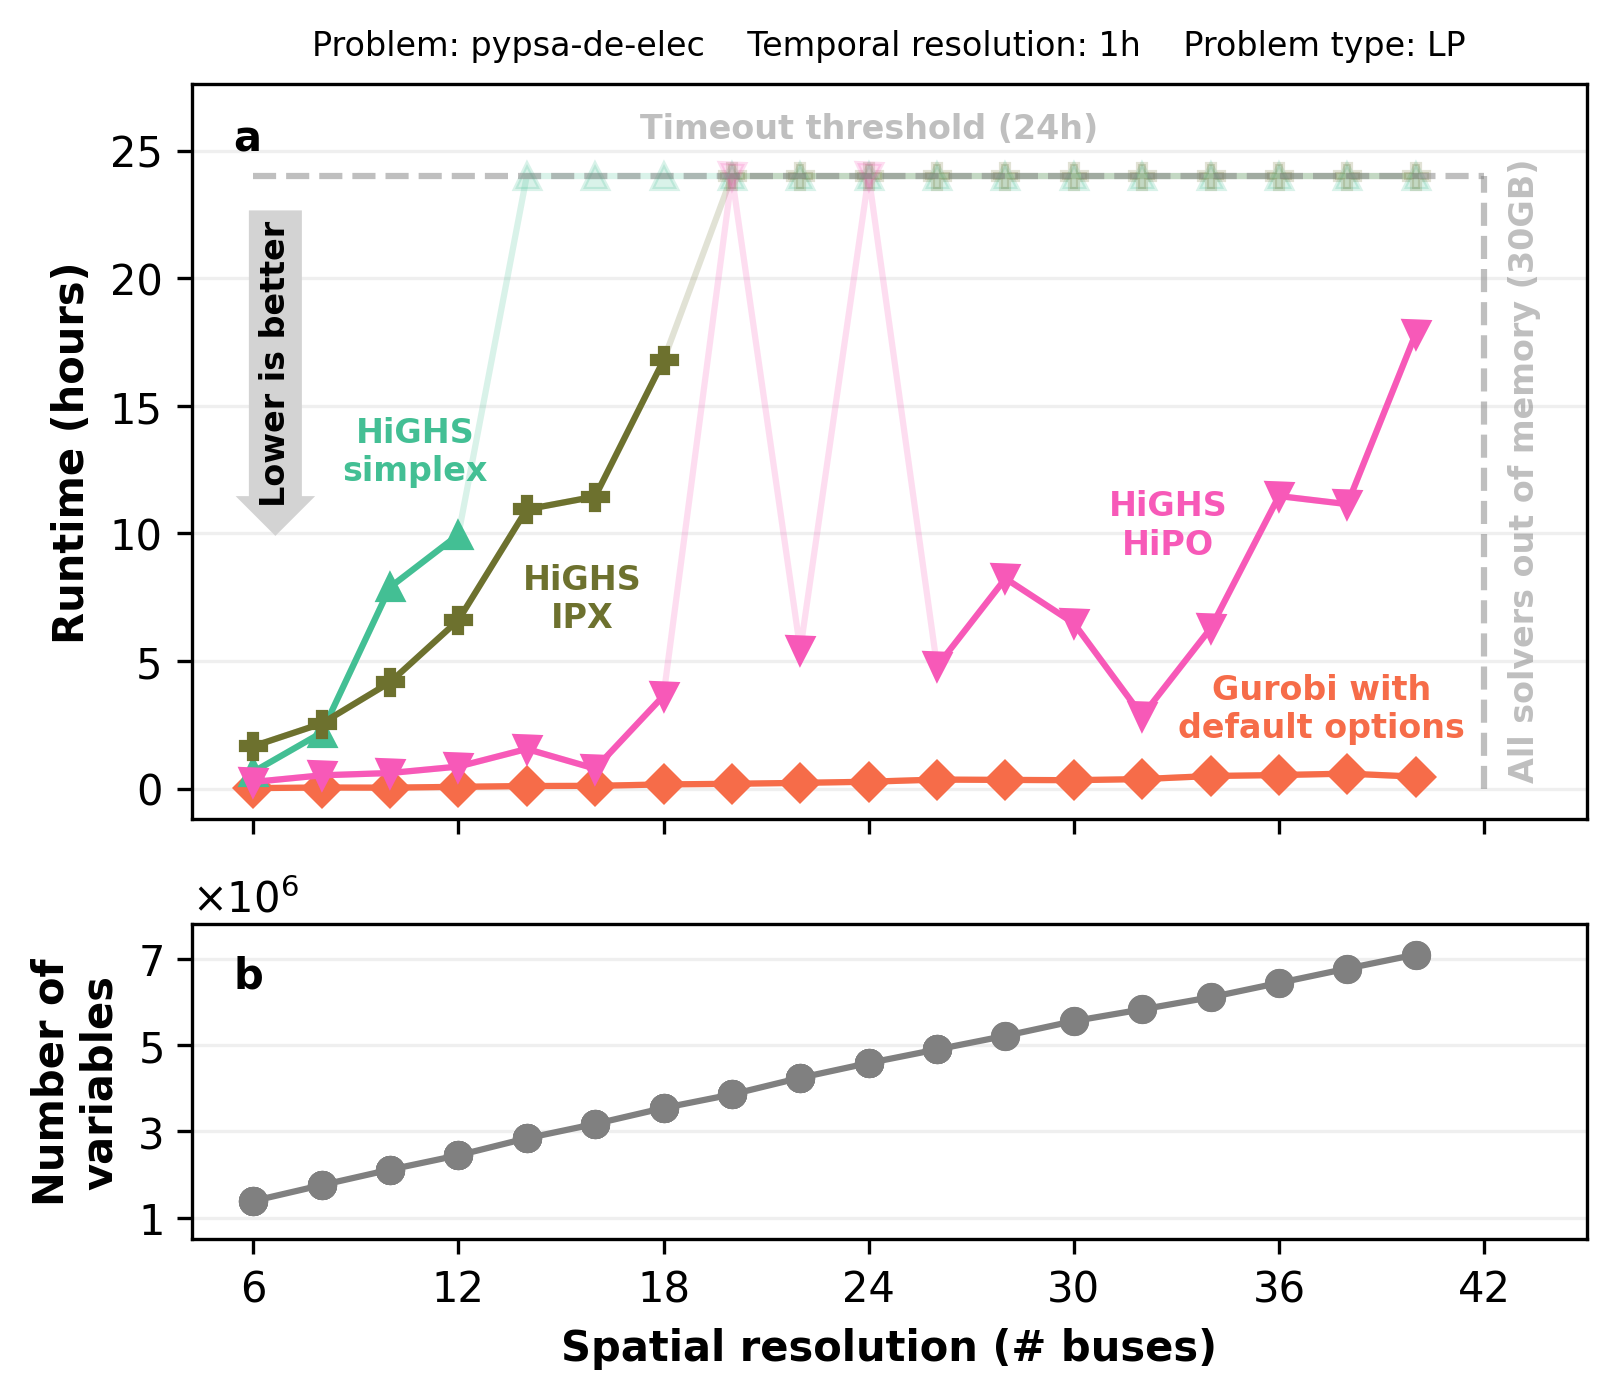

In [77]:
# Initialize the figure and axis.
fig, axs = matplotlib.pyplot.subplots(
    2,
    1,
    figsize=(6, 5),
    dpi=300,
    sharex=True,
    gridspec_kw={"height_ratios": [0.7, 0.3]},
)

# Define the x-axis limits based on the spatial resolution of the benchmark instances.
x_axis_limits = (6, 42)

for solver in solvers:
    # Get the results for the current solver and sort by spatial resolution.
    solver_results = results[results["Solver"] == solver].copy()

    # Convert from seconds to hours for better readability.
    solver_results["Runtime (s)"] = solver_results["Runtime (s)"] / 3600

    # Some runtime values are missing because the problems weren't run; add the values with the timeout threshold for better visualization.
    solver_results = solver_results.set_index("Spatial resolution").reindex(
        numpy.arange(x_axis_limits[0], x_axis_limits[1], 2)
    )
    solver_results["Runtime (s)"] = solver_results["Runtime (s)"].fillna(
        timeout_threshold
    )
    solver_results["Status"] = solver_results["Status"].fillna("TO")
    solver_results = solver_results.reset_index().sort_values(by="Spatial resolution")

    # Plot the runtime of the current solver with the timeout values.
    axs[0].plot(
        solver_results["Spatial resolution"],
        solver_results["Runtime (s)"],
        marker=marker_map.get(solver, None),
        color=color_map.get(solver, None),
        alpha=0.2,
    )

    # If a solver timed out, ran out of memory, or encountered an error, set the runtime to NaN.
    solver_results.loc[
        solver_results["Status"].isin(["TO", "OOM", "ER"]), "Runtime (s)"
    ] = numpy.nan

    # Plot the runtime of the current solver with the timeout values.
    axs[0].plot(
        solver_results["Spatial resolution"],
        solver_results["Runtime (s)"],
        marker=marker_map.get(solver, None),
        label=name_map.get(solver, solver),
        color=color_map.get(solver, None),
    )

# Add a horizontal dashed line for the timeout threshold.
axs[0].hlines(
    timeout_threshold,
    xmin=x_axis_limits[0],
    xmax=x_axis_limits[1],
    linestyles="dashed",
    alpha=0.5,
    color="grey",
)
axs[0].text(
    (x_axis_limits[0] + x_axis_limits[1]) / 2,
    timeout_threshold * 1.05,
    "Timeout threshold (24h)",
    ha="center",
    va="bottom",
    fontsize=8,
    alpha=0.5,
    color="grey",
    weight="bold",
)

# Add a vertical dashed line to indicate that all solvers went out of memory at 42 buses.
axs[0].vlines(
    x_axis_limits[1],
    ymin=0,
    ymax=timeout_threshold,
    linestyles="dashed",
    alpha=0.5,
    color="grey",
)
axs[0].text(
    x_axis_limits[1] + 0.7,
    timeout_threshold * 0.52,
    "All solvers out of memory (30GB)",
    ha="left",
    va="center",
    fontsize=8,
    alpha=0.5,
    color="grey",
    weight="bold",
    rotation=90,
)

# Set the axis labels, ticks, scale, grid, and legend.
axs[0].set_xticks(range(x_axis_limits[0], x_axis_limits[1] + 1, 6))
axs[0].set_xlim(right=x_axis_limits[1] + 3)
axs[0].set_ylabel("Runtime (hours)", weight="bold")
axs[0].set_ylim(top=timeout_threshold * 1.15)
axs[0].yaxis.set_major_formatter(matplotlib.ticker.ScalarFormatter())
axs[0].grid(axis="y", alpha=0.2)
# axs[0].legend(bbox_to_anchor=(0.5, 1.3), loc="center", ncols=2)

# Add an annotation close to each line to indicate the solver name.
axs[0].text(
    0.81,
    0.15,
    "Gurobi with\ndefault options",
    transform=axs[0].transAxes,
    ha="center",
    va="center",
    color=color_map.get("gurobi", None),
    weight="bold",
    fontsize=8,
)
axs[0].text(
    0.16,
    0.5,
    "HiGHS\nsimplex",
    transform=axs[0].transAxes,
    ha="center",
    va="center",
    color=color_map.get("highs", None),
    weight="bold",
    fontsize=8,
)
axs[0].text(
    0.28,
    0.3,
    "HiGHS\nIPX",
    transform=axs[0].transAxes,
    ha="center",
    va="center",
    color=color_map.get("highs-ipm", None),
    weight="bold",
    fontsize=8,
)
axs[0].text(
    0.7,
    0.4,
    "HiGHS\nHiPO",
    transform=axs[0].transAxes,
    ha="center",
    va="center",
    color=color_map.get("highs-hipo", None),
    weight="bold",
    fontsize=8,
)

# Add an arrow and text to indicate that lower runtime is better.
axs[0].text(
    0.06,
    0.62,
    "Lower is better",
    transform=axs[0].transAxes,
    ha="center",
    va="center",
    weight="bold",
    fontsize=8,
    rotation=90,
    bbox=dict(boxstyle="larrow", facecolor="lightgrey", edgecolor="none"),
)

# Add the panel letter.
axs[0].text(0.03, 0.91, "a", transform=axs[0].transAxes, fontsize=10, weight="bold")

# Plot the number of variables by spatial resolution in the top panel.
resolutions_to_plot = results[
    results["Spatial resolution"].isin(range(x_axis_limits[0], x_axis_limits[1]))
]
axs[1].plot(
    resolutions_to_plot["Spatial resolution"],
    resolutions_to_plot["Variables"],
    marker="o",
    color="grey",
)
axs[1].set_ylabel("Number of\nvariables", weight="bold")
axs[1].set_yticks([1e6, 3e6, 5e6, 7e6])
axs[1].set_ylim(0.5e6, 7.8e6)
axs[1].set_xlabel("Spatial resolution (# buses)", weight="bold")
axs[1].grid(axis="y", alpha=0.2)
axs[1].yaxis.get_major_formatter().set_useMathText(True)

# Add the panel letter.
axs[1].text(0.03, 0.8, "b", transform=axs[1].transAxes, fontsize=10, weight="bold")

# Add a note about the benchmark instance.
axs[0].text(
    0.5,
    1.03,
    "Problem: pypsa-de-elec    Temporal resolution: 1h    Problem type: LP",
    ha="center",
    va="bottom",
    transform=axs[0].transAxes,
    fontsize=8,
)

# Save the figure.
fig.savefig("solver_runtime_by_spatial_resolution.png", bbox_inches="tight", dpi=300)